# Incorporating Events into a Simulation

*Note*: This functionality can only be used with the SciPy backend.

## Events

The **PyMCSimMod** package allows one to solve ordinary differential equation (ODE) initial value problems in which discrete changes in state variables may occur at specific points in time. We call these discrete changes in state variables "events." The **PyMCSimMod** package has a built-in mechanism for handling events in which the simulation is stopped at each event and the change to the state variable is made before continuing to the next event. Because this mechanism introduces discontinuities in the state variables, it can only be used with the SciPy backend.

For this demonstration, we will use the classical pharmacokinetic (PK) model illustrated in the figure below.

![Pharmacokinetic Model](pk1.png)

In this ODE model, there are three "compartments" (represented as rectangular boxes in the figure) for which amounts of substance are tracked as state variables: $A_0$ represents the amount of substance in the "exposure compartment" (e.g., the gut in an oral dosing scenario); $A_1$ represents the amount of substance in the "central compartment" (e.g., in the blood of the organism); and $A_2$ represents the amount that has been cleared from the body (e.g., via metabolism or excretion). Thus,

$$
\begin{align}
  \frac{\textrm{d}}{\textrm{d}t}A_0(t) &= -k_{01} A_0(t), \\
  \frac{\textrm{d}}{\textrm{d}t}A_1(t) &= k_{01} A_0(t) - k_{12} A_1(t), \textrm{ and} \\
  \frac{\textrm{d}}{\textrm{d}t}A_2(t) &= k_{12} A_1(t), \\
\end{align}
$$

where $k_{01}$ is the rate constant (with units of one over time) that, along with the value of $A_0$, determines the rate of delivery of the substance to the body and $k_{12}$ is the rate constant (with units of one over time) that, along with the value of $A_1$, determines the rate of clearance from the body. In addition to the state variables, the model includes an "output" variable, $C$, that represents the concentration in the central compartment. The value of this variable is computed as

$$
\begin{equation}
  C(t) = \frac{A_1(t)}{V_\textrm{d}},
\end{equation}
$$

where $V_\textrm{d}$ is a parameter representing the effective volume of the central compartment, or the "volume of distribution." The model includes another output variable,

$$
\begin{equation}
  A_\textrm{tot}(t) = A_0(t) + A_1(t) + A_2(t),
\end{equation}
$$

that represents the total amount of substance in the system. Finally, the model includes an additional state variable that represents the area under the concentration vs. time curve (AUC), as this is a quantity that is often computed in pharmacokinetic analyses. The AUC for the period from time $0$ to time $t$ is given by $\textrm{AUC}(t) = \int_0^t C(\tau) \, \textrm{d}\tau$ and thus the state equation for this quantity is

$$
\begin{equation}
  \frac{\textrm{d}}{\textrm{d}t} \textrm{AUC}(t) = C(t).
\end{equation}
$$

In order to solve an initial value problem for the classical PK model, one needs to provide the values of the three parameters ($k_{01}$, $k_{12}$, and $V_\textrm{d}$) as well as the initial values of the four state variables ($A_0$, $A_1$, $A_2$, and $\textrm{AUC}$). One can also provide a data structure that describes discrete changes to state variables at specific points in time. Details about how to define and use an "events" data structure are provided below.

## MCSim Model Specification

We used the [GNU MCSim](https://www.gnu.org/software/mcsim/) model specification language to implement the Newton's Law of Cooling model. The complete MCSim model specification file for this model, `pk1.model`, can be found in the `extdata` subdirectory of the **MCSimMod** package installation directory.

The model specification file uses the text symbols `A0`, `A1`, `A2`, and `AUC` to represent the state variables $A_0$, $A_1$, $A_2$, and $\textrm{AUC}$, respectively, and the text symbols `k01`, `k12`, and `Vd` to represent the parameters $k_{01}$, $k_{12}$, and $V_\textrm{d}$, respectively. In addition, the text symbols `A0_init`, `A1_init`, `A2_init`, and `AUC_init` represent parameters that can be used to set (via the `updateY0()` method of the `Model` class) the initial conditions of the state variables.

## Building the Model

First, we load the **PyMCSimMod** package as follows.

In [1]:
%load_ext autoreload
%autoreload 2

from pymcsimmod import create_model

Using the following commands, we create a model object (i.e., an instance of the `ScipyModel` class) using the model specification file `pk1.model` that is included in the **PyMCSimMod** package. Again, this functionality is only available with the SciPy backend.

In [2]:
import importlib.resources
with importlib.resources.path('pymcsimmod.data', 'pk1.model') as filename:
    pk1_mod = create_model(filename, backend="scipy")

## Predicting the Blood Concentration of a Substance During Repeated Oral Dosing using Events

Suppose we want to predict the blood concentration of a substance during a 48-hour period when oral doses of 50 mg are provided every 12 hours. Let's assume that the oral absorption rate constant ($k_{01}$) is 1.0 $h^{-1}$, the clearance rate constant ($k_{12}$) is 0.5 $h^{-1}$, and the volume of distribution ($V_\textrm{d}$) is 50 L. These are the default values of those model parameters given in the model specification file. We can change the initial condition for the state variable $A_0$ to zero using the following commands. (Note that all other state variables have default initial conditions of zero based on the model specification file.)

In [3]:
pk1_mod.update_constants(A0_init = 0)

# Verify all initital conditions are 0
print(pk1_mod.parameters)
print(pk1_mod.Y0)

{'A0_init': 0, 'A1_init': 0, 'A2_init': 0, 'AUC_init': 0, 'Vd': 50, 'k01': 1, 'k12': 0.5}
{'A0': 0, 'A1': 0, 'A2': 0, 'AUC': 0}


To specify events, we use the `add_event()` method of the `ScipyModel` class. To easily add multiple events, we can specify an events dataframe and then loop over the rows of that data frame, adding each event in turn. The events data frame will have four columns: `var`, which contains the names of the state variables to be modified in each event; `time`, which contains the times of each event; `value`, which contains the amounts by which the state variables are to be changed; and `method`, which contains descriptions of the methods by which the state variables are to be changed. The event "method" can be "replace," "add," or "multiply." We can create an appropriate data frame for our simulation (and examine it) using the following commands.


In [4]:
import pandas as pd
import numpy as np

events_df = pd.DataFrame({
    'time': np.arange(start = 0, stop = 48 + 12, step = 12) # Note numpy arange excludes the stop value so need to add a step to get to 48
})
events_df['var'] = 'A0'
events_df['value'] = 50
events_df['method'] = 'add'

print(events_df.head())

   time var  value method
0     0  A0     50    add
1    12  A0     50    add
2    24  A0     50    add
3    36  A0     50    add
4    48  A0     50    add


In [5]:
# loop through each event_df row and add event to model
for index, row in events_df.iterrows():
    pk1_mod.add_event(state_var = row['var'],
                      time = row['time'],
                      value = row['value'],
                      method = row['method'])


Finally, we can perform a simulation that provides results for the desired output times (i.e., $t = 0, 0.01, 0.02, \ldots, 48.00$) using the following commands.

In [6]:
# Define output times for simulation.
times = np.arange(start = 0, stop = 48, step = 0.01)

# Run simulation.
results = pk1_mod.run_model(times)
out = results.dataframe
print(out.head())

   time         A0        A1        A2       AUC         C  Atot
0  0.00  50.000000  0.000000  0.000000  0.000000  0.000000  50.0
1  0.01  49.502493  0.496263  0.001244  0.000050  0.009925  50.0
2  0.02  49.009929  0.985124  0.004946  0.000198  0.019702  50.0
3  0.03  48.522268  1.466655  0.011076  0.000443  0.029333  50.0
4  0.04  48.039460  1.940945  0.019595  0.000784  0.038819  50.0


## Examining the Results

The final command shown above  performs a model simulation (incorporating events) and stores the simulation results in a pandas dataframe called `out`. There is one row for each output time, and one column for each state variable and each output variable. Five rows of this data structure are shown below. Note that the independent variable, which is $t$ in the case of the classical PK model, is always labeled "time" in the output data structure.

In [7]:
display(out.iloc[1199:1204])

,time,A0,A1,A2,AUC,C,Atot
1199,11.99,0.000310,0.248462,49.751216,1.990049,0.004969,49.999988
1200,12.00,0.000307,0.247226,49.752455,1.990098,0.004945,49.999988
1201,12.01,49.503117,0.741780,49.755090,1.990204,0.014836,99.999988
1202,12.02,49.010638,1.229289,49.760061,1.990402,0.024586,99.999988
1203,12.03,48.522977,1.709601,49.767410,1.990696,0.034192,99.999988


Note also that each event (in this case, adding 50 to the state variable $A_0$ every 12 hours) occurs immediately *after* the specified "time" of the event (e.g, at 12 hours into the simulation).

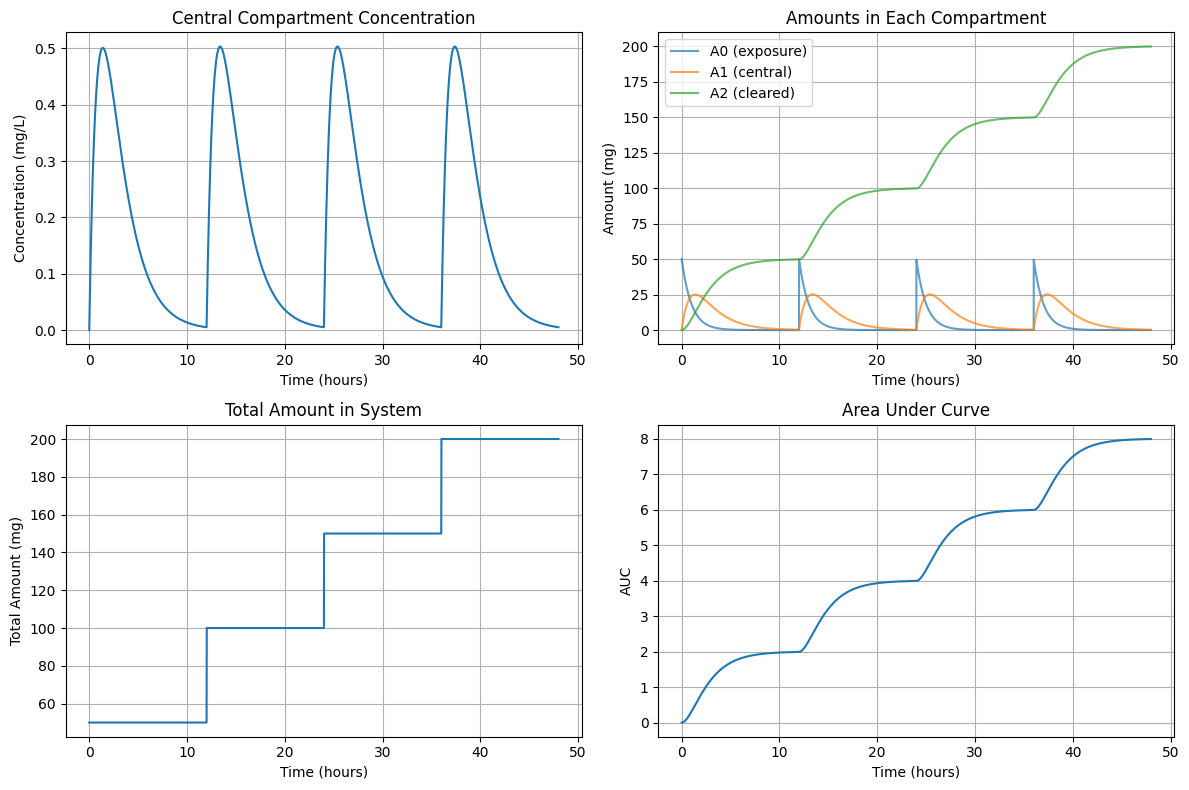

Final concentrations at 48h: 0.005 mg/L
Total AUC: 7.990
Total amount cleared: 199.751 mg


In [8]:
# Visualize the results
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# Plot concentration over time
plt.subplot(2, 2, 1)
plt.plot(out['time'], out['C'])
plt.xlabel('Time (hours)')
plt.ylabel('Concentration (mg/L)')
plt.title('Central Compartment Concentration')
plt.grid(True)

# Plot amounts in each compartment
plt.subplot(2, 2, 2)
plt.plot(out['time'], out['A0'], label='A0 (exposure)', alpha=0.7)
plt.plot(out['time'], out['A1'], label='A1 (central)', alpha=0.7)
plt.plot(out['time'], out['A2'], label='A2 (cleared)', alpha=0.7)
plt.xlabel('Time (hours)')
plt.ylabel('Amount (mg)')
plt.title('Amounts in Each Compartment')
plt.legend()
plt.grid(True)

# Plot total amount
plt.subplot(2, 2, 3)
plt.plot(out['time'], out['Atot'])
plt.xlabel('Time (hours)')
plt.ylabel('Total Amount (mg)')
plt.title('Total Amount in System')
plt.grid(True)

# Plot AUC
plt.subplot(2, 2, 4)
plt.plot(out['time'], out['AUC'])
plt.xlabel('Time (hours)')
plt.ylabel('AUC')
plt.title('Area Under Curve')
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Final concentrations at 48h: {out['C'].iloc[-1]:.3f} mg/L")
print(f"Total AUC: {out['AUC'].iloc[-1]:.3f}")
print(f"Total amount cleared: {out['A2'].iloc[-1]:.3f} mg")